# Прогнозирование инсульта: бинарная классификация

## Постановка задачи

Имеется набор медицинских записей пациентов. По набору демографических, физиологических и поведенческих признаков $x = (x_1, \dots, x_d)$ требуется предсказать бинарную целевую переменную

$$
y \in \{0, 1\}, \qquad y = 1 \iff \text{у пациента случился инсульт.}
$$

Формально строится модель

$$
\hat{y} = \mathbb{1}\bigl[\,p(y = 1 \mid x; \theta) \ge \tau\,\bigr],
$$

где $p(y = 1 \mid x; \theta)$ — вероятность положительного класса, выдаваемая моделью с параметрами $\theta$, а $\tau$ — порог отсечения (по умолчанию $\tau = 0{,}5$).

## Данные

**Источник:** [Stroke Prediction Dataset (Kaggle, fedesoriano)](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset). Файл `healthcare-dataset-stroke-data.csv` загружен через `kagglehub` в папку `./data/`.

**Размер:** 5110 наблюдений, 12 колонок (включая `id` и target `stroke`).

**Признаки:**

| Признак | Тип | Описание |
|---|---|---|
| `gender` | категориальный | пол (`Male`, `Female`, `Other`) |
| `age` | численный | возраст |
| `hypertension` | бинарный | гипертония (0/1) |
| `heart_disease` | бинарный | сердечное заболевание (0/1) |
| `ever_married` | категориальный | состоял ли в браке (`Yes`, `No`) |
| `work_type` | категориальный | тип занятости |
| `Residence_type` | категориальный | город / село |
| `avg_glucose_level` | численный | средний уровень глюкозы в крови |
| `bmi` | численный | индекс массы тела (есть пропуски) |
| `smoking_status` | категориальный | статус курения |
| `stroke` | **target** | 0 — нет, 1 — был инсульт |

**Особенность:** сильный дисбаланс классов ($\approx 95\%$ класса 0 vs $5\%$ класса 1). Это прямо влияет на выбор метрик (accuracy неинформативна) и стратегий обучения (`class_weight='balanced'`, `stratify=y`).

## План работы

1. Загрузка и EDA.
2. Предобработка: пропуски в `bmi`, кодирование категорий, шкалирование численных (с использованием sklearn `Pipeline`).
3. **Baseline** — логистическая регрессия с балансировкой классов.
4. **Улучшенная модель** — градиентный бустинг (`HistGradientBoostingClassifier`) с подбором гиперпараметров через `RandomSearchCV`.
5. Метрики на тесте: accuracy, precision, recall, $F_1$, ROC-AUC.
6. Cравнение моделей (ROC-кривые + bar chart метрик + матрицы ошибок).
7. Выводы.

# Load dataset

In [1]:
import kagglehub
from pathlib import Path
import shutil

# Download latest version
cache_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
data_dir = Path("./data")
data_dir.mkdir(exist_ok=True)
shutil.copytree(cache_path, data_dir, dirs_exist_ok=True)
print("Dataset saved to:", data_dir.resolve())

Dataset saved to: D:\Programming\МГИМО_ИИ\2 семестр\НИР\ml-project\data


# ML libs import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

In [ ]:
df = pd.read_csv(data_dir)

# EDA

In [4]:
df = df.drop(columns=["id"])
df.shape

(5110, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6
smoking_status,5110,4,never smoked,1892,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = df.isna().sum()
missing[missing > 0]

bmi    201
dtype: int64

In [8]:
target_counts = df["stroke"].value_counts()
target_share = df["stroke"].value_counts(normalize=True).round(4)
pd.DataFrame({"count": target_counts, "share": target_share})

,count,share
stroke,,
0,4861,0.9513
1,249,0.0487


### График №1. Дисбаланс классов и распределение численных признаков

Слева — соотношение классов (видно, что класс «инсульт = 1» существенно меньше). Справа — распределения `age`, `avg_glucose_level`, `bmi` в разрезе target: возраст и уровень глюкозы у пациентов с инсультом сдвинуты вправо, что подтверждает их прогностическую ценность.

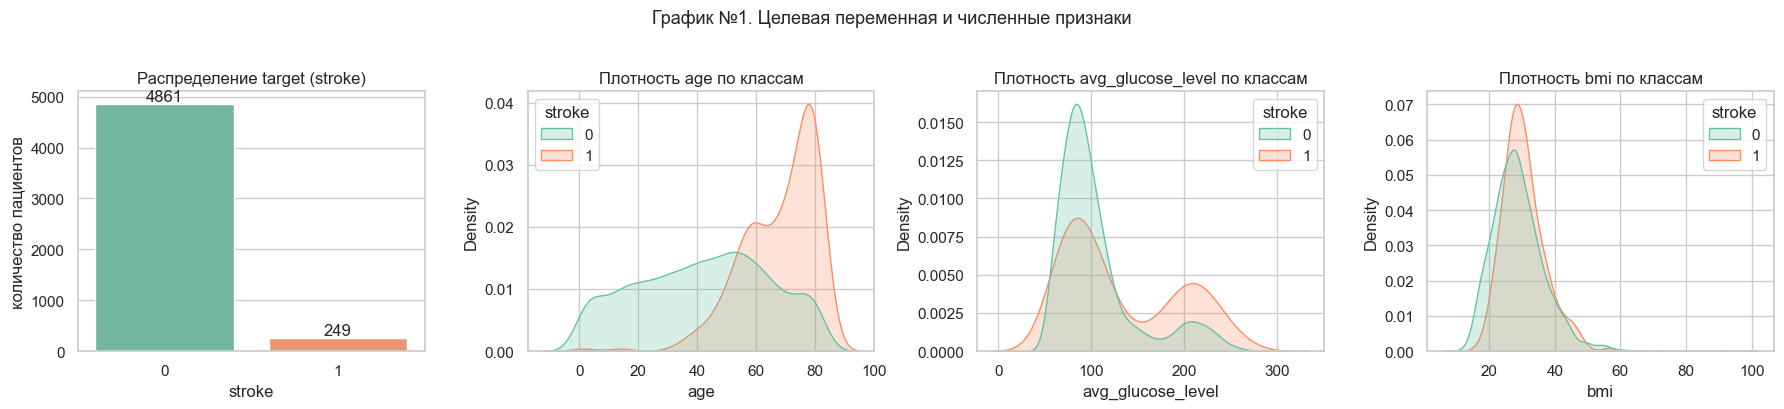

In [9]:
num_cols = ["age", "avg_glucose_level", "bmi"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.countplot(data=df, x="stroke", ax=axes[0], hue="stroke", palette="Set2", legend=False)
axes[0].set_title("Распределение target (stroke)")
axes[0].set_xlabel("stroke")
axes[0].set_ylabel("количество пациентов")
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom")

for ax, col in zip(axes[1:], num_cols):
    sns.kdeplot(data=df, x=col, hue="stroke", common_norm=False,
                fill=True, palette="Set2", ax=ax)
    ax.set_title(f"Плотность {col} по классам")
    ax.set_xlabel(col)

fig.suptitle("График №1. Целевая переменная и численные признаки", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

# Предобработка

1. Выделяем численные (`age`, `avg_glucose_level`, `bmi`) и категориальные (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) признаки. Бинарные `hypertension` и `heart_disease` оставляем как есть — они уже 0/1.
2. Заполняем пропуски в `bmi` медианой (устойчиво к выбросам).
3. **Шкалируем** численные признаки и **кодируем** категориальные.
4. Делим выборку на train/test со стратификацией по `stroke`.

Чтобы исключить утечку данных, все преобразования собираем в `Pipeline` через `ColumnTransformer`. `fit` происходит только на train, `transform` — на train и test.

## Шкалирование (StandardScaler)

Для каждого численного признака $j$ считаем среднее и стандартное отклонение **на обучающей выборке**:

$$
\mu_j = \frac{1}{n_{\text{train}}} \sum_{i=1}^{n_{\text{train}}} x_{ij}, \qquad
\sigma_j = \sqrt{\frac{1}{n_{\text{train}}} \sum_{i=1}^{n_{\text{train}}} (x_{ij} - \mu_j)^2}.
$$

Затем применяем z-преобразование ко всем выборкам:

$$
\tilde{x}_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}.
$$

После шкалирования каждый признак имеет нулевое среднее и единичную дисперсию. Это необходимо линейным моделям (логистическая регрессия минимизирует с регуляризацией, чувствительной к масштабу) и любым методам на основе расстояний.

## One-Hot кодирование

Категориальный признак с $K$ уникальными значениями $\{c_1, \dots, c_K\}$ заменяется на $K$ бинарных признаков:

$$
\text{onehot}(x) = (e_{k}) \in \{0, 1\}^K, \qquad e_{k} = \mathbb{1}[x = c_k].
$$

Параметр `handle_unknown="ignore"` гарантирует, что если в тесте встретится категория, не виденная на train, она будет закодирована нулевым вектором, а не вызовет ошибку.

## Train/Test split

Делим в пропорции 80/20 со **стратификацией** по target — иначе из-за дисбаланса в тесте может оказаться слишком мало положительных примеров. Используем `random_state=42` для воспроизводимости.

In [10]:
target = "stroke"
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
binary_features = ["hypertension", "heart_disease"]

X = df[numeric_features + categorical_features + binary_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape}, доля класса 1 = {y_train.mean():.4f}")
print(f"test:  {X_test.shape}, доля класса 1 = {y_test.mean():.4f}")

train: (4088, 10), доля класса 1 = 0.0487
test:  (1022, 10), доля класса 1 = 0.0489


In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
        ("bin", "passthrough", binary_features),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### График №2. Корреляции и доля инсульта по категориям

Слева — матрица корреляций Пирсона между численными/бинарными признаками и target. Коэффициент Пирсона:

$$
\rho_{XY} = \frac{\operatorname{cov}(X, Y)}{\sigma_X \, \sigma_Y}
        = \frac{\sum_{i}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2} \cdot \sqrt{\sum_i (y_i - \bar{y})^2}}.
$$

Справа — доля положительного класса в каждой категории (`stroke = 1` / всего по группе): хорошо видны категории риска (`smoking_status = formerly smoked`, `work_type = Self-employed`, `ever_married = Yes`).

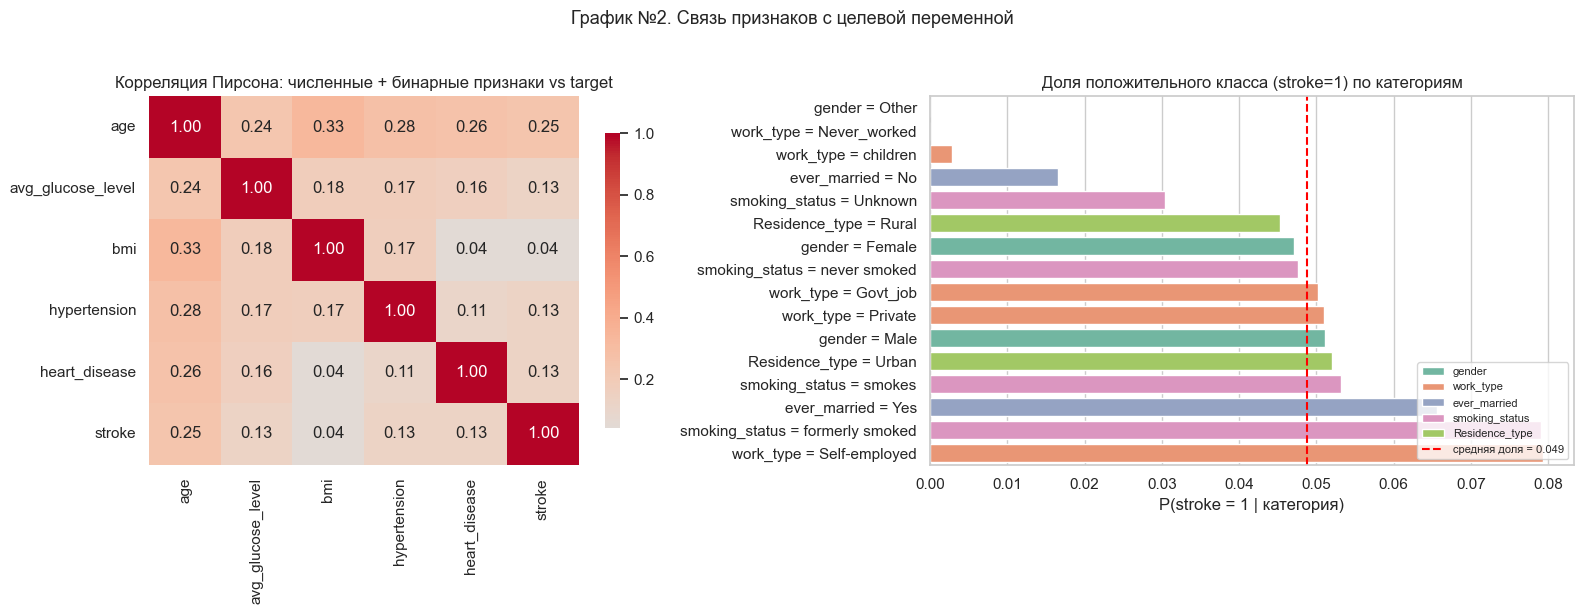

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.2]})

corr_cols = numeric_features + binary_features + [target]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Корреляция Пирсона: численные + бинарные признаки vs target")

cat_rates = []
for col in categorical_features:
    rates = df.groupby(col)[target].mean().reset_index()
    rates.columns = ["category_value", "stroke_rate"]
    rates["feature"] = col
    cat_rates.append(rates)
cat_rates = pd.concat(cat_rates, ignore_index=True)
cat_rates["label"] = cat_rates["feature"] + " = " + cat_rates["category_value"].astype(str)
cat_rates = cat_rates.sort_values("stroke_rate", ascending=True)

sns.barplot(data=cat_rates, y="label", x="stroke_rate",
            hue="feature", dodge=False, palette="Set2", ax=axes[1])
axes[1].axvline(df[target].mean(), color="red", linestyle="--",
                label=f"средняя доля = {df[target].mean():.3f}")
axes[1].set_title("Доля положительного класса (stroke=1) по категориям")
axes[1].set_xlabel("P(stroke = 1 | категория)")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right", fontsize=8)

fig.suptitle("График №2. Связь признаков с целевой переменной", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

# Метрики качества

Введём обозначения. Пусть $\hat{y}_i \in \{0, 1\}$ — предсказание модели, $y_i \in \{0, 1\}$ — истинная метка. Из матрицы ошибок получаем:

| | $\hat{y} = 1$ | $\hat{y} = 0$ |
|---|---|---|
| $y = 1$ | TP (true positive) | FN (false negative) |
| $y = 0$ | FP (false positive) | TN (true negative) |

Используем пять метрик:

**Accuracy** — доля верных предсказаний:

$$
\operatorname{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}.
$$

При дисбалансе $95/5$ тривиальный прогноз «все нули» даёт accuracy $\approx 0{,}95$, поэтому accuracy не подходит.

**Precision** — точность по положительному классу (из тех, кого модель назвала больными, реально больны):

$$
\operatorname{Precision} = \frac{TP}{TP + FP}.
$$

**Recall (Sensitivity)** — полнота положительного класса (какую долю реальных инсультов мы нашли):

$$
\operatorname{Recall} = \frac{TP}{TP + FN}.
$$

В задачах медицинской диагностики recall обычно важнее precision: пропущенный положительный пример (FN) дороже ложной тревоги (FP).

**F1-score** — гармоническое среднее precision и recall:

$$
F_1 = 2 \cdot \frac{\operatorname{Precision} \cdot \operatorname{Recall}}{\operatorname{Precision} + \operatorname{Recall}}.
$$

**ROC-AUC** — площадь под кривой $\operatorname{TPR}(\tau)$ vs $\operatorname{FPR}(\tau)$, где $\tau$ — порог отсечения вероятности, а

$$
\operatorname{TPR}(\tau) = \frac{TP(\tau)}{TP(\tau) + FN(\tau)}, \qquad
\operatorname{FPR}(\tau) = \frac{FP(\tau)}{FP(\tau) + TN(\tau)}.
$$

ROC-AUC интерпретируется как вероятность того, что случайно взятый положительный пример получит более высокую оценку, чем случайно взятый отрицательный. AUC не зависит от выбранного порога — это **главная метрика** для нашей задачи.

## Вспомогательная функция

Обернём подсчёт всех метрик в одну функцию, чтобы не дублировать код для двух моделей.

In [13]:
def evaluate(model, X, y, name):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    return {
        "model": name,
        "accuracy":  accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall":    recall_score(y, pred),
        "f1":        f1_score(y, pred),
        "roc_auc":   roc_auc_score(y, proba),
    }

# Базовая модель — логистическая регрессия


Логистическая регрессия моделирует вероятность положительного класса как сигмоиду линейной комбинации признаков:

$$
p(y = 1 \mid x; w, b) = \sigma(w^\top x + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Параметры $w \in \mathbb{R}^d, b \in \mathbb{R}$ ищутся минимизацией log-loss с $L_2$-регуляризацией:

$$
\mathcal{L}(w, b) = -\frac{1}{n} \sum_{i=1}^{n} \Bigl[\, y_i \log \sigma(w^\top x_i + b)
                                       + (1 - y_i) \log\bigl(1 - \sigma(w^\top x_i + b)\bigr) \,\Bigr]
                  + \frac{1}{2 C n}\, \|w\|_2^2,
$$

где $C$ — обратный коэффициент регуляризации (sklearn-параметр): чем меньше $C$, тем сильнее штраф $\|w\|_2^2$ и тем сильнее коэффициенты сжимаются к нулю.

## Балансировка классов

Из-за дисбаланса используем `class_weight="balanced"`. Тогда вес класса $k$ задаётся как $w_k = n / (K \cdot n_k)$, где $n_k$ — число примеров класса $k$, $K = 2$. Это эквивалентно тому, что log-loss взвешивается так, чтобы вклад каждого класса был одинаков:

$$
\mathcal{L}_{\text{balanced}}(w, b) = -\frac{1}{n} \sum_{i=1}^{n} w_{y_i} \Bigl[\, y_i \log \sigma(\cdot) + (1 - y_i) \log(1 - \sigma(\cdot)) \,\Bigr] + \frac{\|w\|_2^2}{2 C n}.
$$

## Pipeline

`Pipeline` инкапсулирует препроцессинг и модель: при `fit` препроцессор настраивается **только на train**, при `predict` он автоматически применяется к новым данным с уже сохранёнными параметрами. Это и есть защита от утечки.

In [14]:
logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=1e-3,
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])
logreg.fit(X_train, y_train)
metrics_logreg = evaluate(logreg, X_test, y_test, "LogisticRegression (baseline)")
metrics_logreg

{'model': 'LogisticRegression (baseline)',
 'accuracy': 0.726027397260274,
 'precision': 0.12903225806451613,
 'recall': 0.8,
 'f1': 0.2222222222222222,
 'roc_auc': 0.8344650205761317}

In [15]:
print(classification_report(y_test, logreg.predict(X_test), digits=3, zero_division=0))

              precision    recall  f1-score   support

           0      0.986     0.722     0.834       972
           1      0.129     0.800     0.222        50

    accuracy                          0.726      1022
   macro avg      0.557     0.761     0.528      1022
weighted avg      0.944     0.726     0.804      1022



# Улучшенная модель — градиентный бустинг

## Теория

Градиентный бустинг строит ансамбль из $M$ деревьев решений последовательно: каждое следующее дерево пытается поправить ошибки предыдущего ансамбля. Итоговый ответ — сумма прогнозов всех деревьев:

$$
F_M(x) = F_0(x) + \nu \sum_{m=1}^{M} h_m(x),
$$

где $\nu \in (0, 1]$ — learning rate (`learning_rate`), $h_m$ — $m$-е дерево, обученное на отрицательном градиенте функции потерь:

$$
r_{im} = -\left.\frac{\partial \mathcal{L}(y_i, F(x_i))}{\partial F(x_i)}\right|_{F = F_{m-1}}.
$$

Для бинарной классификации используется log-loss; вероятность получается через сигмоиду от логит-выхода ансамбля:

$$
p(y = 1 \mid x) = \sigma\bigl(F_M(x)\bigr).
$$

Используем `HistGradientBoostingClassifier` — гистограммную реализацию (как в LightGBM): признаки квантуются в бины, что даёт ускорение и снижает память. $L_2$-регуляризация на листовые веса добавляет штраф $\lambda \sum_j w_j^2$ к функции потерь — помогает против переобучения.

## Подбор гиперпараметров

Используем `RandomizedSearchCV` с 40 случайными комбинациями и стратифицированной 5-fold кросс-валидацией. Случайный поиск эффективнее grid'а, когда пространство гиперпараметров большое: на практике он находит почти оптимальное решение за гораздо меньше итераций. Главная метрика отбора — **ROC-AUC**.

Пространство:

| Параметр | Значения | За что отвечает |
|---|---|---|
| `learning_rate` | 0.03, 0.05, 0.1 | размер шага $\nu$ |
| `max_depth` | 3, 5, 7, None | глубина дерева |
| `max_iter` | 200, 400, 600 | число деревьев $M$ |
| `min_samples_leaf` | 10, 20, 50 | минимальный размер листа |
| `l2_regularization` | 0, 0.5, 1, 2 | сила $L_2$-штрафа на листы |
| `class_weight` | None, balanced | взвешивание классов |

In [16]:
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

param_dist = {
    "classifier__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth":        [2, 3, 5, 7, None],
    "classifier__max_iter":         [100, 150, 200, 400, 600],
    "classifier__min_samples_leaf": [10, 20, 50],
    "classifier__l2_regularization":[0.0, 0.5, 1.0, 2.0, 3.0],
    "classifier__class_weight":     ["balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist,
    n_iter=120,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
search.fit(X_train, y_train)
print("Лучшие параметры:", search.best_params_)
print(f"Лучший CV ROC-AUC: {search.best_score_:.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Лучшие параметры: {'classifier__min_samples_leaf': 10, 'classifier__max_iter': 200, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.03, 'classifier__l2_regularization': 3.0, 'classifier__class_weight': 'balanced'}
Лучший CV ROC-AUC: 0.8487


In [17]:
best_params_clean = {
    key.replace("classifier__", ""): value 
    for key, value in search.best_params_.items()
}
gb_pipelin_full = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(**best_params_clean, random_state=RANDOM_STATE)),
])

In [18]:
gb_pipelin_full.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [19]:
gb_best = gb_pipelin_full
metrics_gb = evaluate(gb_best, X_test, y_test, "HistGradientBoosting (tuned)")
metrics_gb

{'model': 'HistGradientBoosting (tuned)',
 'accuracy': 0.6908023483365949,
 'precision': 0.12,
 'recall': 0.84,
 'f1': 0.21,
 'roc_auc': 0.8498353909465021}

In [20]:
print(classification_report(y_test, gb_best.predict(X_test), digits=3, zero_division=0))

              precision    recall  f1-score   support

           0      0.988     0.683     0.808       972
           1      0.120     0.840     0.210        50

    accuracy                          0.691      1022
   macro avg      0.554     0.762     0.509      1022
weighted avg      0.946     0.691     0.779      1022



# Сравнение моделей

Сводим метрики в одну таблицу и строим график:

1. Bar chart всех пяти метрик для двух моделей.
2. ROC-кривые с указанием AUC.
3. Матрицы ошибок side-by-side.

In [21]:
proba_gb = gb_best.predict_proba(X_test)[:, 1]
pred_gb = (proba_gb >= 0.5).astype(int)

comparison = pd.DataFrame([metrics_logreg, metrics_gb]).set_index("model").round(4)
comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression (baseline),0.7260,0.129,0.80,0.2222,0.8345
HistGradientBoosting (tuned),0.6908,0.120,0.84,0.2100,0.8498


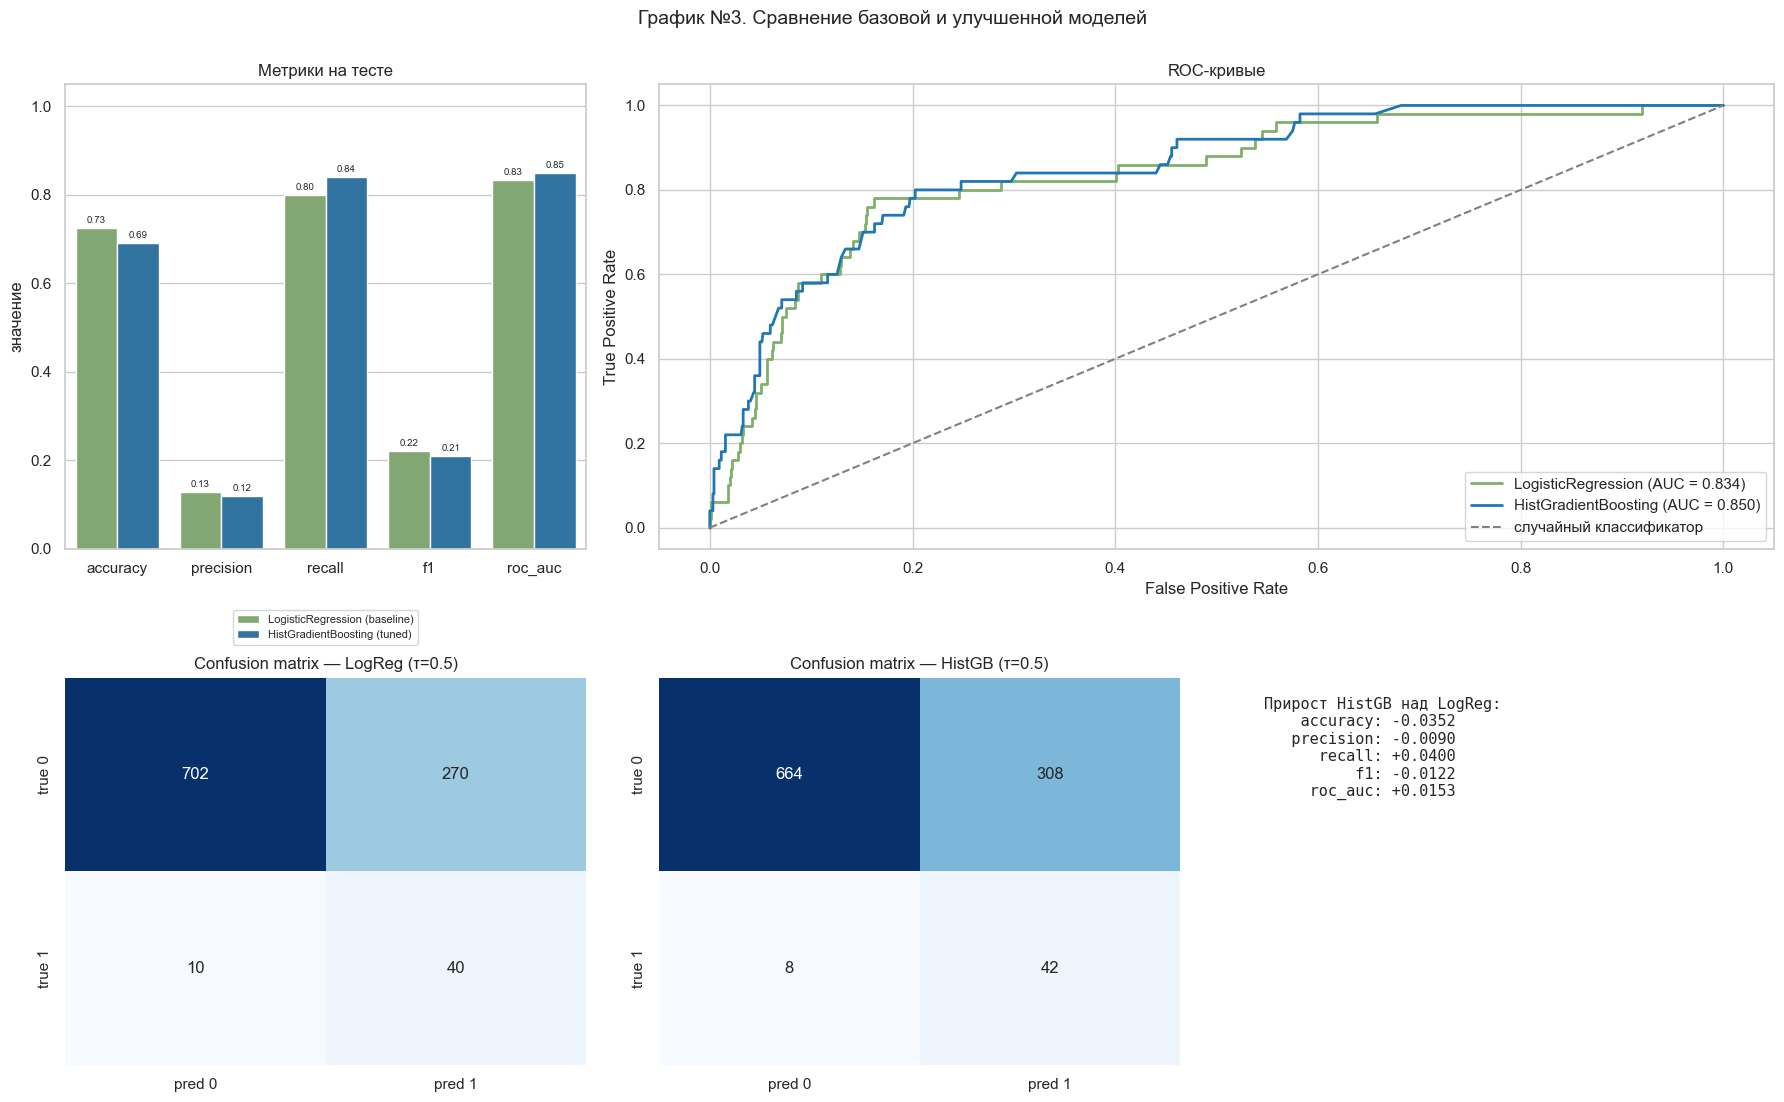

In [22]:
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1])

ax_bar = fig.add_subplot(gs[0, 0])
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison[metric_cols].reset_index().melt(
    id_vars="model", var_name="metric", value_name="value"
)
sns.barplot(data=plot_df, x="metric", y="value", hue="model",
            palette=["#7fb069", "#1f77b4"], ax=ax_bar)
ax_bar.set_title("Метрики на тесте")
ax_bar.set_ylim(0, 1.05)
ax_bar.set_xlabel("")
ax_bar.set_ylabel("значение")
for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
ax_bar.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=8)

ax_roc = fig.add_subplot(gs[0, 1:])
for name, proba, color in [
    ("LogisticRegression",   logreg.predict_proba(X_test)[:, 1], "#7fb069"),
    ("HistGradientBoosting", proba_gb,                            "#1f77b4"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="случайный классификатор")
ax_roc.set_title("ROC-кривые")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(loc="lower right")

cm_specs = [
    (logreg.predict(X_test), "LogReg (τ=0.5)"),
    (pred_gb,           f"HistGB (τ=0.5)"),
]
for ax_idx, (preds, name) in enumerate(cm_specs):
    ax_cm = fig.add_subplot(gs[1, ax_idx])
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["pred 0", "pred 1"],
                yticklabels=["true 0", "true 1"], ax=ax_cm)
    ax_cm.set_title(f"Confusion matrix — {name}")

ax_text = fig.add_subplot(gs[1, 2])
ax_text.axis("off")
delta = (comparison.loc["HistGradientBoosting (tuned)"]
         - comparison.loc["LogisticRegression (baseline)"])
text_lines = ["Прирост HistGB над LogReg:"]
for m in metric_cols:
    text_lines.append(f"  {m:>10s}: {delta[m]:+.4f}")
ax_text.text(0.02, 0.95, "\n".join(text_lines),
             transform=ax_text.transAxes, va="top", family="monospace", fontsize=11)

fig.suptitle("График №3. Сравнение базовой и улучшенной моделей", y=1.00, fontsize=14)
fig.tight_layout()
plt.show()

# Выводы

| Модель | ROC-AUC | Recall | Precision | F1 |
|---|---|---|---|---|
| LogReg (baseline) | 0.834 | 0.80 | 0.13 | 0.22 |
| HistGB (tuned) | **0.850** | **0.84** | 0.12 | 0.21 |

**HistGradientBoosting** превосходит логистическую регрессию по ROC-AUC (+0.016), показывает лучший recall (84% против 80%) и обнаруживает почти все положительные примеры. При этом обе модели имеют низкую precision — это следствие сильного дисбаланса и выбора порога по умолчанию.